In [1]:
import pandas as pd
import numpy as np
# from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df1_columns_to_use = [
    'Months to Last Follow-up',
    'Date of Injury',
    'Time of Injury',
    'Date to OR at MEE',
    'Time to OR at MEE',
    'Time from Injury to OR',
    'Date of presentation to MEE',
    'Day of Week of Presentation',
    'Time of presentation to MEE',
    'Eye',
    'Post-op VA at last follow-up',
    'Date of Last Follow-up',
    'Age at time of injury',
    'Sex',
    'Race',
    'Ethnicity',
    'Mechanism (Rupture v Perforation v Penetration)',
    'Mechanism',
    'Patient location during Injury',
    'Presenting VA',
    'APD (Y/N)',
    'IOFB (Y/N)',
    'Zone I',
    'Zone II',
    'Zone III',
    'Maximal Zone of Injury',
    'Uveal Prolapse (Y/N)',
    'Lensectomy (Y/N)',
    'Post-op Sight-improving Surgery (Y/N)',
    'Endophthalmitis (Y/N)',
    'Patient Profession',
    'Insurance Type',
    'State',
    'Pre-globe Ocular Surgeries in traumatized eye (if known)',
    'Pre-globe Ocular Comorbidities in truamatized eye (if known)',
    'Retinal Detachment (Y/N)',
    'Choroidal Hemorrhage (Y/N)',
    'Scleral Buckle (Y/N)',
    'PPV (Y/N)',
    'Vitreous Hemorrhage (Y/N)',
    'Lens Capsular Violation (Y/N)',
    'Lens taken primarily (Y/N)',
    'Lens taken secondarily (Y/N)',
    'Pseudo/Aphakic prior or due to trauma (Y/N)',
    'Self-sealed (Y/N)',
    'Disinsertion of Rectus (Y/N)',
    'PK (Y/N)',
    'Enucleation (Y/N)',
    'Date of Enucleation',
    'Primary or Secondary Enucleation',
    'Enucleation or Evisceration',
    'Indication for Enucleation',
    'Additional surgeries necessary',
    'Next Additional surgery necessary ',
    'Date of next surgery'
]

df = pd.read_csv('Original Combined Dataset 2012-2022.csv', usecols= df1_columns_to_use)

<Axes: ylabel='Density'>

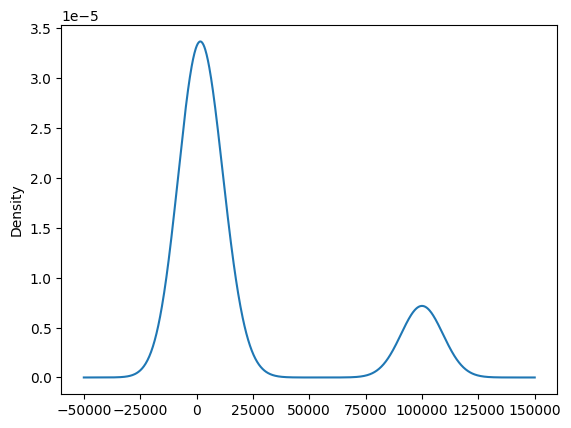

In [2]:
#df = df[df['Post-op VA at last follow-up'].str.match("F/F|unable|20/30|20/40") == False]
df['Post-op VA at last follow-up'].astype(np.float64).plot(kind="kde")

In [3]:
for col in df:
    uniq_vals = (df[col].unique())
    if uniq_vals is not None and 1 < uniq_vals.size < 3:
        if sorted(uniq_vals) == ["N", "Y"]:
            df[col] = df[col].astype(bool)
        else:
            df[col] = df[col].astype("category")
            # Left-eye / right-eye | female / male might be better as categorical rather than boolean

In [4]:

#Cleaning Data Start ------------------

#dropping patients with missing presenting VA, post op VA, endophthalmitis, time to OR
for col in ('Post-op VA at last follow-up', 'Presenting VA', 'Endophthalmitis (Y/N)',
            'Time to OR at MEE', 'Months to Last Follow-up', 'Time from Injury to OR'):
    df = df.dropna(subset=[col])

#converting different spellings of rupture, perforation, penetration -> rup, pen, perf
#df['Mechanism (Rupture v Perforation v Penetration)'].describe(include='all')
df['Mechanism (Rupture v Perforation v Penetration)'] = df['Mechanism (Rupture v Perforation v Penetration)'].str.strip().str.casefold()
#rup = ['rup']
#pen = ['pen']
#perf = ['perf']

#creating columns for rupture, penetration, perforation as binary variables
#condition_rup = list(map(df['Mechanism (Rupture v Perforation v Penetration)'].str.contains, rup))
#condition_pen = list(map(df['Mechanism (Rupture v Perforation v Penetration)'].str.contains, pen))
#condition_perf = list(map(df['Mechanism (Rupture v Perforation v Penetration)'].str.contains, perf))
for cat in "rupture", "penetration", 'perforation':
    df[cat.title()] = df.loc[df['Mechanism (Rupture v Perforation v Penetration)'] == cat]['Mechanism (Rupture v Perforation v Penetration)']


#deleting patients with non-numerical presenting VA
df = df[df['Presenting VA'].str.match("F/F|unable|20/30|20/40") == False]

In [5]:
#converting presenting VA to float
df['Presenting VA'] = df['Presenting VA'].astype(float)

#assuming no value stored for retinal detachment = no retinal detachment
df['Retinal Detachment (Y/N)'] = df['Retinal Detachment (Y/N)'].fillna('N')


#converting date to year
df['Year to OR at MEE'] = 2023 - pd.DatetimeIndex(df['Date to OR at MEE']).year

#Transforming strings to numbers
Le = LabelEncoder()
df['Sex'] = Le.fit_transform(df['Sex'])
df['Day of Week of Presentation'] = Le.fit_transform(df['Day of Week of Presentation'])
df['Eye'] = Le.fit_transform(df['Eye'])
df['Rupture'] = Le.fit_transform(df['Rupture'])
df['Penetration'] = Le.fit_transform(df['Penetration'])
df['Perforation'] = Le.fit_transform(df['Perforation'])
df['Retinal Detachment (Y/N)'] = Le.fit_transform(df['Retinal Detachment (Y/N)'])
df['APD (Y/N)'] = Le.fit_transform(df['APD (Y/N)'])
df['Endophthalmitis (Y/N)'] = Le.fit_transform(df['Endophthalmitis (Y/N)'])
df['IOFB (Y/N)'] = Le.fit_transform(df['IOFB (Y/N)'])
df['Zone I'] = Le.fit_transform(df['Zone I'])
df['Zone II'] = Le.fit_transform(df['Zone II'])
df['Zone III'] = Le.fit_transform(df['Zone III'])
df['Lensectomy (Y/N)'] = Le.fit_transform(df['Lensectomy (Y/N)'])
df['Uveal Prolapse (Y/N)'] = Le.fit_transform(df['Uveal Prolapse (Y/N)'])

#Visual acuity values count fingers (CF), hand motion (HM), light perception (LP), and no light perception (NLP) were converted to 2.0, 2.4, 2.7, and 3.0, respectively
# (low vision key in spreadsheet) -> logMAR equivilant
#CF = 2,000 -> 2.0
#HM = 6,000 -> 2.4
#LP = 10,000 -> 2.7
#NLP = 100,000 -> 3.0
#PMID: 28299240
#PMID: 18766368
#converting low VA to logMAR equivilant

def va_to_cat(va):
    if va < -0.30: return "6/3"
    elif va < -0.20: return "6/3.8"
    elif va < -0.10: return "6/4.8"
    elif va < 0.1: return "6/7.5"
    elif va < 0.2: return "6/9.5"
    elif va < 0.3: return "6/12"
    elif va < 0.4: return "6/15"
    elif va < 0.5: return "6/18"
    elif va < 0.6: return "6/24"
    elif va < 0.7: return "6/30"
    elif va < 0.8: return "6/38"
    elif va < 0.9: return "6/48"
    elif va < 0: return "6/6"
    elif va < 1: return "6/60"
    raise ValueError(va)

for col in 'Presenting VA', 'Post-op VA at last follow-up':
    #print(col, len(df.index))
    for find, replace in ([100000], 3), ([10000], 2.7), ([6000], 2.4), ([2000], 2):
        df[col] = df[col].replace(find, replace)
    #df["cat " + col] = df[col].copy().apply(va_to_cat)
    #df.to_csv('out.csv')

    #Converting Snellen VA to logMAR
    df.loc[df[col] >5, col] = np.log10((df[col]/20))

In [6]:
#creating specific columns for race

'''
for cat in "White", "Black", "Asian", "American Indian or Alaskan Native", "Native Hawaiian Or Other Pacific Islander":
    df[{
        "American Indian or Alaskan Native": "Indian",
        "Native Hawaiian Or Other Pacific Islander": "Hawaiian"
       }.get(cat, cat)] = df.loc[df['Race'] == cat]['Race'].fillna(0).map(lambda s: s == cat).astype(bool)

#creating specific column for Ethnicity
df['Hispanic'] = df.loc[df['Ethnicity'] == 'Hispanic']['Ethnicity'].fillna(0).map(lambda s: s == 'Hispanic').astype(bool)
'''

White = []
Black = []
Asian = []
Indian = []
Hawaiian = []

for value in df['Race']:
    if value == "White":
        White.append(1)
    else:
        White.append(0)

    if value == "Black":
        Black.append(1)
    else:
        Black.append(0)

    if value == "Asian":
        Asian.append(1)
    else:
        Asian.append(0)

    if value == "American Indian or Alaskan Native":
        Indian.append(1)
    else:
        Indian.append(0)

    if value == "Native Hawaiian Or Other Pacific Islander":
        Hawaiian.append(1)
    else:
        Hawaiian.append(0)

df['White'] = White
df['Black'] = Black
df['Asian'] = Asian
df['Indian'] = Indian
df['Hawaiian'] = Hawaiian

#creating specific column for Ethnicity
Hispanic = []
for value in df['Ethnicity']:
    if value == "Hispanic":
        Hispanic.append(1)
    else:
        Hispanic.append(0)
df['Hispanic'] = Hispanic

#creating specific columns for mechanism

Fall = []
Projectile = []
Nail = []
Blunt = []
Glass = []
Assault = []
Wood = []
MVC = []
Wire = []
Knife = []
Metal = []

for value in df['Mechanism']:
    if "fall".casefold() in value.casefold():
        Fall.append(1)
    else:
        Fall.append(0)

    if value == "Projectile":
        Projectile.append(1)
    else:
        Projectile.append(0)

    if value == "Nail":
        Nail.append(1)
    else:
        Nail.append(0)

    if value == "Blunt":
        Blunt.append(1)
    else:
        Blunt.append(0)

    if value == "Glass":
        Glass.append(1)
    else:
        Glass.append(0)

    if value == "Assault":
        Assault.append(1)
    else:
        Assault.append(0)

    if value == "Wood":
        Wood.append(1)
    else:
        Wood.append(0)

    if value == "MVC":
        MVC.append(1)
    else:
        MVC.append(0)

    if value == "Wire":
        Wire.append(1)
    else:
        Wire.append(0)

    if value == "Knife/Blade":
        Knife.append(1)
    else:
        Knife.append(0)

    if value == "Metal":
        Metal.append(1)
    else:
        Metal.append(0)

df['Fall'] = Fall
df['Projectile'] = Projectile
df['Nail'] = Nail
df['Blunt'] = Blunt
df['Glass'] = Glass
df['Assault'] = Assault
df['Wood'] = Wood
df['MVC'] = MVC
df['Wire'] = Wire
df['Knife'] = Knife
df['Metal'] = Metal

In [7]:
#df['Time to OR at MEE'][0], df['Time from Injury to OR'][0]
from datetime import timedelta

def clock_to_timedelta(clock):
    #print(clock)
    hours, minutes = map(int, clock.split(":"))
    assert hours > -1
    assert minutes > -1
    return pd.Timedelta(hours=hours, minutes=minutes)

row = df.head(1)

In [8]:
df["datetime of injury"] = pd.to_datetime(df["Date of Injury"] + " " + df["Time of Injury"])
df["datetime of OR at MEE"] = pd.to_datetime(df["Date to OR at MEE"] + " " + df["Time to OR at MEE"])

#converting time from presentation to OR into minutes

df[#'Time from Injury to OR (minutes)'
  'Time to OR (minutes)'] =  ((df["datetime of OR at MEE"] - df["datetime of injury"]) / pd.Timedelta(hours=1)).fillna(0)
# Cleaning Data End ---------------

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

lm = LinearRegression()
rf = RandomForestRegressor()
dt = DecisionTreeRegressor()
svr = make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.2))
mlp = MLPRegressor()

continuous_cols = (#continuous inputs (omitting 'Year to OR at MEE' and 'Months to Last Follow-up' final model)
    'Age at time of injury',
    'Time to OR (minutes)',
    #'Year to OR at MEE',
    'Presenting VA',
    #'Months to Last Follow-up'
    )
categorical_cols = (#categorical inputs
    'Sex',
    'Eye',
    'Rupture',
    'Penetration',
    'Perforation',
    'Endophthalmitis (Y/N)',
    'Retinal Detachment (Y/N)',
    'APD (Y/N)',
    'IOFB (Y/N)',
    'Zone I',
    'Zone II',
    'Zone III',
    'Lensectomy (Y/N)',
    'Uveal Prolapse (Y/N)',
    'White',
    'Black',
    'Asian',
    'Indian',
    'Hawaiian',
    'Hispanic',
    'Fall',
    'Projectile',
    'Nail',
    'Blunt',
    'Glass',
    'Assault',
    'Wood',
    'MVC',
    'Wire',
    'Knife',
    'Metal')
col_to_predict = 'Post-op VA at last follow-up'

X = df[list(continuous_cols + categorical_cols)]
y = df[col_to_predict]

#creating hold-out partition to test best performing model (20% of original data)
X_train, X_test_holdout, y_train, y_test_holdout = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler().fit(X_train)
#X_scaled = scaler.transform(X_train)
model_params = {
    
    'random_forest': {
        'model': RandomForestRegressor(),
        'params' : {
            'n_estimators': [50, 100, 500]
        }
    },
    'ada_boost': {
        'model': AdaBoostRegressor(),
        'params' : {
            'n_estimators': np.linspace(start = 100, stop = 1000, num = 2, dtype=int)
        }
    },
    'gradient_boosting': {
        'model': GradientBoostingRegressor(),
        'params' : {
           'n_estimators': np.linspace(start = 100, stop = 500, num = 3, dtype=int)
          #  'max_depth': [3, 5, 20],
           # 'learning_rate': [0, 1, 10],
           # 'criterion': ['friedman_mse', 'squared_error', 'squared_error']
        }
    },
 'extra_trees': {
        'model': ExtraTreesRegressor(),
        'params' : {
            'n_estimators': np.linspace(start = 100, stop = 1000, num = 2, dtype=int)
        }
    },
    'lasso': {
        'model': linear_model.Lasso(),
        'params' : {
            #'alpha': [int(x) for x in np.linspace(start = 0.1, stop = 1, num = 10)]
        }
    },

}
scores = []

for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], scoring='neg_mean_absolute_error', cv=10, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    
results = pd.DataFrame(scores,columns=['model','best_score','best_params'])
results

,model,best_score,best_params
0,random_forest,-0.591501,{'n_estimators': 500}
1,ada_boost,-0.669032,{'n_estimators': 100}
2,gradient_boosting,-0.578348,{'n_estimators': 100}
3,extra_trees,-0.605184,{'n_estimators': 1000}
4,lasso,-0.999466,{}


In [11]:
#re-training best performing model (random forest) and testing on 20% holdout group
from sklearn import metrics
rf = RandomForestRegressor(n_estimators = 100).fit(X_train, y_train)
regressor_prediction = rf.predict(X_test_holdout)
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test_holdout, regressor_prediction))

from sklearn.metrics import mean_squared_error

rms = mean_squared_error(y_test_holdout, regressor_prediction, squared=False)
print('RMS:', rms)

Mean Absolute Error: 0.6087701443934066
RMS: 0.8354022864914883


<Axes: xlabel='Presenting VA', ylabel='Post-op VA at last follow-up'>

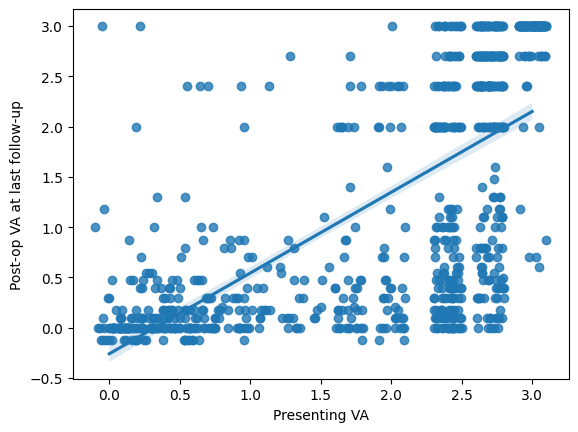

In [12]:
#Begin plotting
import seaborn as sns 
from matplotlib import pyplot as plt 
sns.regplot(x=df['Presenting VA'], y=df[col_to_predict], x_jitter = 0.1)

<Axes: xlabel='Age at time of injury', ylabel='Post-op VA at last follow-up'>

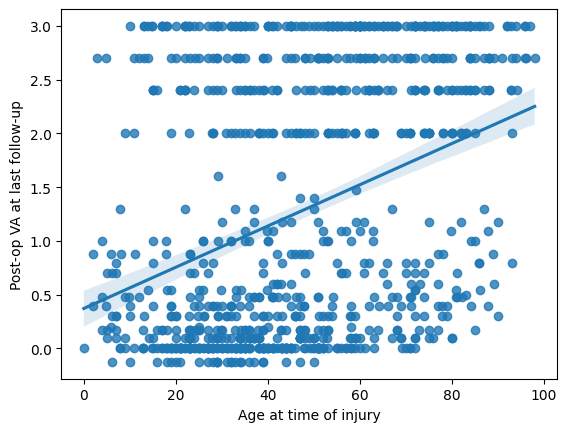

In [13]:
sns.regplot(x=df['Age at time of injury'], y=df[col_to_predict], x_jitter = 0.1)

<Axes: xlabel='Time to OR (minutes)', ylabel='Post-op VA at last follow-up'>

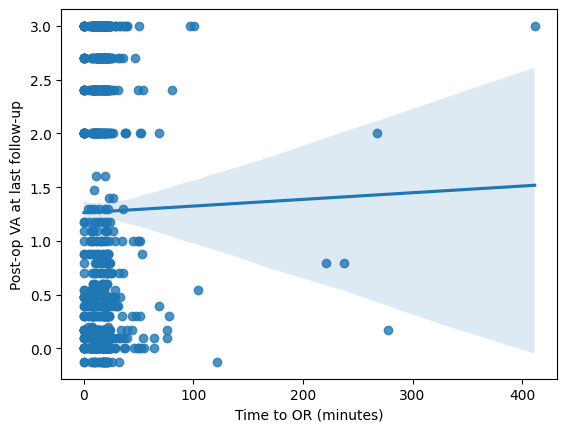

In [14]:
sns.regplot(x=df['Time to OR (minutes)'], y=df[col_to_predict], x_jitter = 0.1)

Text(0, 0.5, 'Frequency')

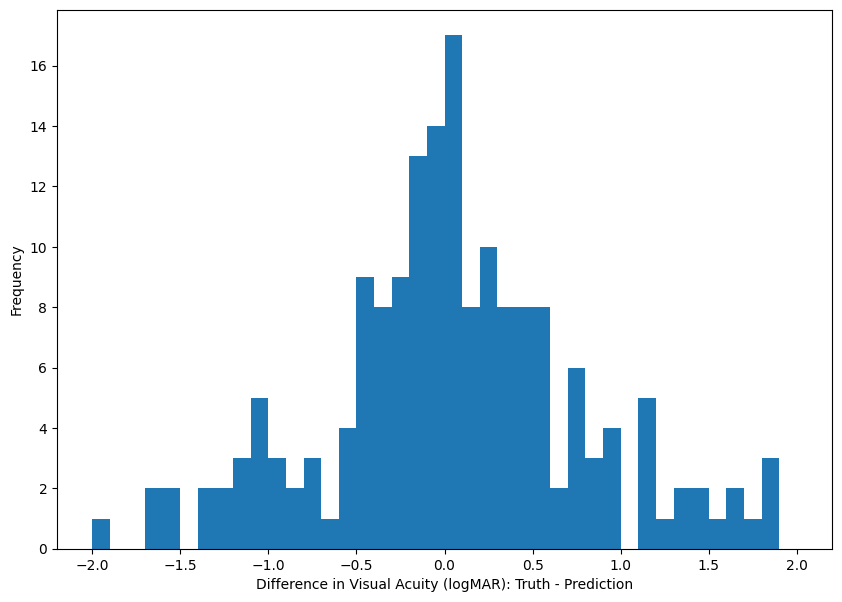

In [15]:
results = y_test_holdout - regressor_prediction
fig, ax = plt.subplots(figsize =(10, 7))
ax.hist(results, bins = [-2,-1.9,-1.8,-1.7,-1.6,-1.5,-1.4,-1.3,-1.2,-1.1,-1,-.9,-.8,-.7,-.6,-.5,-.4,-.3,-.2,-.1,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2])
plt.xlabel("Difference in Visual Acuity (logMAR): Truth - Prediction")
plt.ylabel("Frequency")

Text(0, 0.5, 'Actual Final VA (logMAR)')

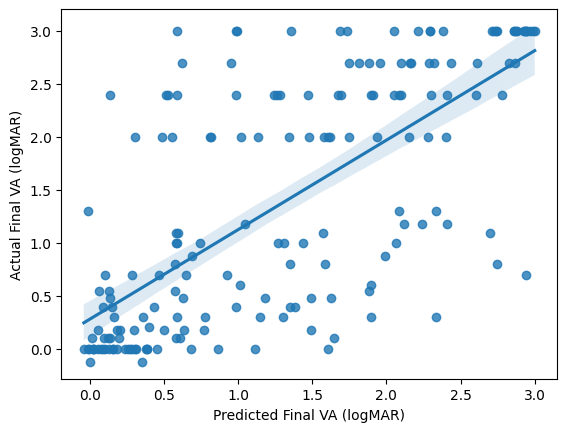

In [16]:
sns.regplot(x=regressor_prediction, y=y_test_holdout)
plt.xlabel("Predicted Final VA (logMAR)")
plt.ylabel("Actual Final VA (logMAR)")

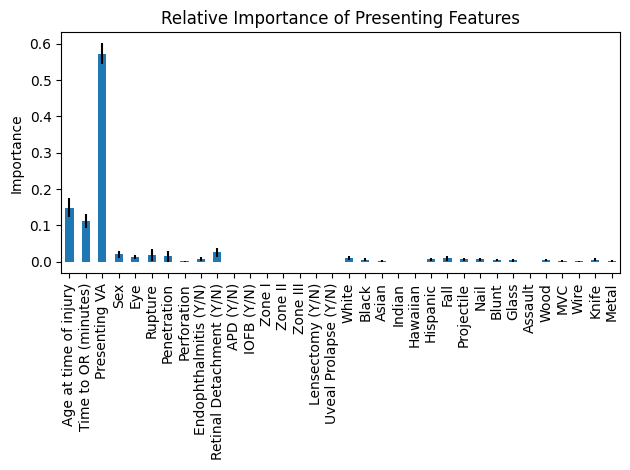

In [17]:
#plotting feature importance

importances = rf.feature_importances_
feature_names = [
    

 #continuous inputs
    'Age at time of injury', 
    'Time to OR (minutes)',
   # 'Year to OR at MEE',
    'Presenting VA',
   # 'Months to Last Follow-up',
    #categorical inputs
    'Sex', 
    'Eye',     
    'Rupture', 
    'Penetration', 
    'Perforation', 
    'Endophthalmitis (Y/N)', 
    'Retinal Detachment (Y/N)', 
    'APD (Y/N)', 
    'IOFB (Y/N)',
    'Zone I',
    'Zone II',
    'Zone III',
    'Lensectomy (Y/N)',
    'Uveal Prolapse (Y/N)',
    'White',
    'Black',
    'Asian',
    'Indian',
    'Hawaiian',
    'Hispanic',
    'Fall',
    'Projectile',
    'Nail',
    'Blunt',
    'Glass',
    'Assault',
    'Wood',
    'MVC',
    'Wire',
    'Knife',
    'Metal'
]
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
forest_importances = pd.Series(importances, index=feature_names)
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Relative Importance of Presenting Features")
ax.set_ylabel("Importance")
fig.tight_layout()

<Axes: ylabel='Density'>

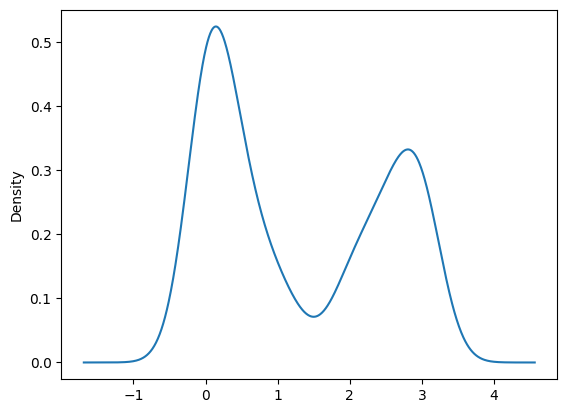

In [18]:
df[col_to_predict].plot(kind='kde')

In [19]:
from itertools import chain


#import tensorflow_transform as tft
import tensorflow_decision_forests as tfdf

tf_df = df.copy()

for col in 'Presenting VA', 'Post-op VA at last follow-up':
    tf_df[col] = tf_df[col].apply(va_to_cat)

def split_dataset(dataset, test_ratio=0.20):
    """Splits a panda dataframe in two."""
    test_indices = np.random.rand(len(dataset)) < test_ratio
    return dataset[~test_indices], dataset[test_indices]



train_ds_pd, test_ds_pd = split_dataset(tf_df[list(chain.from_iterable((continuous_cols, categorical_cols, (col_to_predict,))))])
print("{} examples in training, {} examples for testing.".format(
    len(train_ds_pd), len(test_ds_pd)))

train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_ds_pd, label=col_to_predict)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test_ds_pd, label=col_to_predict)

2023-03-29 14:26:18.502236: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-03-29 14:26:18.520859: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-03-29 14:26:18.521075: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-03-29 14:26:19.035458: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


ValueError: 2.4

In [ ]:
# Specify the model.
model_1 = tfdf.keras.RandomForestModel(verbose=2)

# Train the model.
model_1.fit(train_ds)